In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# TLKM

In [ ]:
ticker = "TLKM.JK"
start_date = "2021-12-31"
end_date = "2023-12-18"

data = yf.download(ticker, start=start_date, end=end_date)

print(data)

[*********************100%%**********************]  1 of 1 completed
              Open    High     Low   Close    Adj Close     Volume
Date                                                              
2022-01-03  4060.0  4180.0  4050.0  4180.0  3869.650635   65937900
2022-01-04  4180.0  4200.0  4150.0  4170.0  3860.393311   42984700
2022-01-05  4150.0  4190.0  4030.0  4050.0  3749.302734  119584700
2022-01-06  4090.0  4120.0  4030.0  4120.0  3814.105469   89197500
2022-01-07  4120.0  4190.0  4090.0  4170.0  3860.393311   68415100
...            ...     ...     ...     ...          ...        ...
2023-12-11  3870.0  3980.0  3850.0  3980.0  3980.000000   99365500
2023-12-12  3940.0  3950.0  3890.0  3910.0  3910.000000   58707700
2023-12-13  3870.0  3920.0  3870.0  3920.0  3920.000000   54386800
2023-12-14  3880.0  3960.0  3880.0  3940.0  3940.000000   70705300
2023-12-15  3940.0  3980.0  3900.0  3980.0  3980.000000  109064200

[477 rows x 6 columns]


# 50,50,50,60




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 30, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_1 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_2 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_3 (LSTM)               (None, 60)                2

In [ ]:
# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 20s 126ms/step - loss: 0.0749
Epoch 2/200
22/22 [==============================] - 2s 90ms/step - loss: 0.0276
Epoch 3/200
22/22 [==============================] - 2s 78ms/step - loss: 0.0241
Epoch 4/200
22/22 [==============================] - 1s 52ms/step - loss: 0.0225
Epoch 5/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0189
Epoch 6/200
22/22 [==============================] - 1s 39ms/step - loss: 0.0178
Epoch 7/200
22/22 [==============================] - 1s 40ms/step - loss: 0.0162
Epoch 8/200
22/22 [==============================] - 1s 40ms/step - loss: 0.0192
Epoch 9/200
22/22 [==============================] - 1s 39ms/step - loss: 0.0171
Epoch 10/200
22/22 [==============================] - 1s 40ms/step - loss: 0.0152
Epoch 11/200
22/22 [==============================] - 1s 45ms/step - loss: 0.0159
Epoch 12/200
22/22 [==============================] - 1s 66ms/step - loss: 0.0149
Epoch 13/200
22/22 [===

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 17ms/step
Root mean squared error: 31.705939434861254


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 16ms/step
Root mean squared error: 48.80008424209413


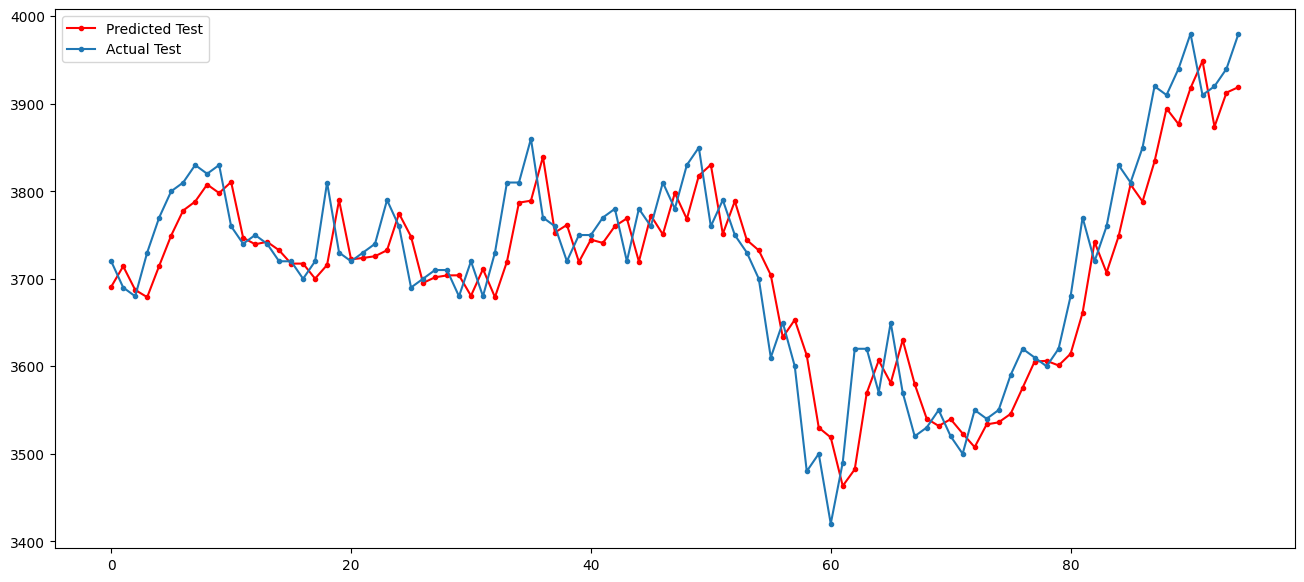

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 28ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     3956.461426
1   2023-12-19     3924.251465
2   2023-12-20     3907.731934
3   2023-12-21     3896.433838
4   2023-12-22     3886.086670
5   2023-12-25     3876.571533
6   2023-12-26     3867.771484
7   2023-12-27     3859.420166
8   2023-12-28     3851.307617
9   2023-12-29     3843.270508
10  2024-01-01     3835.203613
11  2024-01-02     3827.052979
12  2024-01-03     3818.801025
13  2024-01-04     3810.458496
14  2024-01-05     3802.064209
15  2024-01-08     3793.679932
16  2024-01-09     3785.373291
17  2024-01-10     3777.205566
18  2024-01-11     3769.208984
19  2024-01-12     3761.433350
20  2024-01-15     3753.920166
21  2024-01-16     3746.679443


In [ ]:
predicted_df['Prediksi_Harga']=predicted_df['Prediksi_Harga'].round(decimals=0)

In [ ]:
predicted_df.to_csv('TLKM.csv')

In [ ]:
test_data = close_prices[training_data_len:]
test_data

Date
2023-08-03    3720.0
2023-08-04    3690.0
2023-08-07    3680.0
2023-08-08    3730.0
2023-08-09    3770.0
               ...  
2023-12-11    3980.0
2023-12-12    3910.0
2023-12-13    3920.0
2023-12-14    3940.0
2023-12-15    3980.0
Name: Close, Length: 95, dtype: float64

In [ ]:
df_test_tlkm = pd.DataFrame(test_data)
df_test_tlkm['Testing'] = predictions.round(decimals=0)
df_test_tlkm

,Close,Testing
Date,,
2023-08-03,3720.0,3691.0
2023-08-04,3690.0,3714.0
2023-08-07,3680.0,3687.0
2023-08-08,3730.0,3679.0
2023-08-09,3770.0,3715.0
...,...,...
2023-12-11,3980.0,3918.0
2023-12-12,3910.0,3949.0
2023-12-13,3920.0,3874.0


In [ ]:
df_test_tlkm.to_csv('TLKM_testing.csv')

In [ ]:
df_train_tlkm = close_prices[: training_data_len]
df_train_tlkm

Date
2022-01-03    4180.0
2022-01-04    4170.0
2022-01-05    4050.0
2022-01-06    4120.0
2022-01-07    4170.0
               ...  
2023-07-27    3720.0
2023-07-28    3720.0
2023-07-31    3720.0
2023-08-01    3750.0
2023-08-02    3690.0
Name: Close, Length: 382, dtype: float64

In [ ]:
df_train_tlkm.to_csv('TLKM_train.csv')